# Renewable Energy Output Prediction using Artificial Neural Networks (ANN)

A self-contained script to predict solar energy output (kWh) from weather data using a multilayer perceptron with backpropagation.

## Architecture
* **Input Layer:** 5 neurons (`irradiance`, `temperature`, `wind_speed`, `humidity`, `hour`)
* **Hidden Layer 1:** 10 neurons, ReLU activation
* **Hidden Layer 2:** 8 neurons, ReLU activation
* **Output Layer:** 1 neuron, Linear activation (regression)

**Loss:** Mean Squared Error (MSE)  
**Optimizer:** Adam (`learning_rate=0.001`)

**Author:** Academic Project — Intelligent Systems Course  
**Reference:** Negnevitsky, M. (2005). Artificial Intelligence: A Guide to Intelligent Systems. Chapter 6: Artificial Neural Networks.

### Setup, Imports, and Configuration
Setting up libraries, random seeds for reproducibility, and project paths.

In [2]:
import os
import sys
import json
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import requests

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.linear_model import LinearRegression

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# ── Configuration ──────────────────────────────────────────────
LAT, LON = 40.4, -3.7                     # Madrid, Spain
START_YEAR, END_YEAR = 2020, 2020         # Full year (leap year = 8784 hours)
FEATURES = ['irradiance', 'temperature', 'wind_speed', 'humidity', 'hour']
TARGET = 'energy_kwh'
EPOCHS = 150
BATCH_SIZE = 32
LEARNING_RATE = 0.001
PATIENCE = 10

# Directories
BASE_DIR = os.path.abspath('')
FIGURES_DIR = os.path.join(BASE_DIR, 'figures')
MODEL_PATH_KERAS = os.path.join(BASE_DIR, 'best_model.keras')
MODEL_PATH = os.path.join(BASE_DIR, 'best_model.h5')
RAW_SOLAR_PATH = os.path.join(BASE_DIR, 'solar_data_raw.csv')
RAW_WEATHER_PATH = os.path.join(BASE_DIR, 'weather_data_raw.csv')
CLEAN_PATH = os.path.join(BASE_DIR, 'solar_data_clean.csv')
RESULTS_PATH = os.path.join(BASE_DIR, 'results_table.csv')

os.makedirs(FIGURES_DIR, exist_ok=True)

# Reproducibility
np.random.seed(42)
tf.random.set_seed(42)

print("=" * 60)
print("Renewable Energy ANN — Solar Output Prediction")
print("=" * 60)

Renewable Energy ANN — Solar Output Prediction


### Step 1: Data Collection
Fetching hourly PV output data from the PVGIS v5.2 API and weather data from the NASA POWER API.

In [4]:
def fetch_pvgis_data(lat=LAT, lon=LON, startyear=START_YEAR, endyear=END_YEAR):
    """Fetch hourly PV output data from the PVGIS v5.2 API."""
    url = (
        f"https://re.jrc.ec.europa.eu/api/v5_2/seriescalc"
        f"?lat={lat}&lon={lon}&startyear={startyear}&endyear={endyear}"
        f"&pvcalculation=1&peakpower=1&loss=14&pvtechchoice=crystSi"
        f"&angle=35&aspect=0&optimalangles=0&outputformat=json"
    )
    resp = requests.get(url, timeout=120)
    if resp.status_code != 200:
        raise RuntimeError(f"PVGIS API error: {resp.status_code} — {resp.text[:500]}")
    data = resp.json()
    hourly = data['outputs']['hourly']
    df = pd.DataFrame(hourly)
    df['datetime'] = pd.to_datetime(df['time'], format='%Y%m%d:%H%M')
    df = df.drop(columns=['time'])
    df = df.rename(columns={
        'P': 'energy_kwh',
        'G(i)': 'irradiance',
        'H_sun': 'sun_height',
        'T2m': 'temperature',
        'WS10m': 'wind_speed',
        'Int': 'intensity'
    })
    # Convert W to kWh for 1 kWp system
    df['energy_kwh'] = df['energy_kwh'] / 1000.0
    # Round datetime to nearest hour for merging
    df['datetime'] = df['datetime'].dt.round('h')
    return df

def fetch_nasa_power_data(lat=LAT, lon=LON, start='20200101', end='20201231'):
    """Fetch weather data from NASA POWER API (no key required)."""
    url = (
        f"https://power.larc.nasa.gov/api/temporal/hourly/point"
        f"?parameters=T2M,RH2M,WS10M,ALLSKY_SFC_SW_DWN"
        f"&community=RE&longitude={lon}&latitude={lat}"
        f"&start={start}&end={end}&format=JSON"
    )
    resp = requests.get(url, timeout=120)
    if resp.status_code != 200:
        raise RuntimeError(f"NASA POWER API error: {resp.status_code}")
    data = resp.json()
    params = data['properties']['parameter']
    df = pd.DataFrame({
        'datetime': pd.to_datetime(list(params['T2M'].keys()), format='%Y%m%d%H'),
        'temperature_nasa': list(params['T2M'].values()),
        'humidity': list(params['RH2M'].values()),
        'wind_speed_nasa': list(params['WS10M'].values()),
        'ghi': list(params['ALLSKY_SFC_SW_DWN'].values()),
    })
    return df

print("[Step 1] Fetching solar data from PVGIS API...")
# Fetch or load data
if os.path.exists(RAW_SOLAR_PATH) and os.path.exists(RAW_WEATHER_PATH):
    print("  Using cached raw data...")
    df_solar = pd.read_csv(RAW_SOLAR_PATH, parse_dates=['datetime'])
    df_weather = pd.read_csv(RAW_WEATHER_PATH, parse_dates=['datetime'])
else:
    print("  Downloading from PVGIS (this may take a moment)...")
    df_solar = fetch_pvgis_data()
    print(f"  PVGIS: {len(df_solar)} records fetched.")

    print("  Downloading from NASA POWER...")
    df_weather = fetch_nasa_power_data()
    print(f"  NASA POWER: {len(df_weather)} records fetched.")

    df_solar.to_csv(RAW_SOLAR_PATH, index=False)
    df_weather.to_csv(RAW_WEATHER_PATH, index=False)
    print("  Raw data saved to CSV.")

[Step 1] Fetching solar data from PVGIS API...
  PVGIS: 8784 records fetched.
  NASA POWER: 8784 records fetched.
  Raw data saved to CSV.


### Step 2: Merge & Preprocess
Merge the datasets based on the datetime, handle missing values, and extract time-based features.

In [5]:
print("[Step 2] Merging and preprocessing data...")

# Merge on datetime
df_weather_sub = df_weather[['datetime', 'humidity', 'ghi']].copy()
df = pd.merge(df_solar, df_weather_sub, on='datetime', how='inner')
print(f"  Merged dataset: {df.shape[0]} rows × {df.shape[1]} columns")

# Handle missing values (column means)
missing_before = df.isnull().sum().sum()
df = df.fillna(df.mean(numeric_only=True))
print(f"  Missing values filled: {missing_before} → {df.isnull().sum().sum()}")

# Time feature engineering
df['hour'] = df['datetime'].dt.hour
df['day_of_week'] = df['datetime'].dt.dayofweek
df['month'] = df['datetime'].dt.month
df['season'] = df['month'].map({
    12: 0, 1: 0, 2: 0,
    3: 1, 4: 1, 5: 1,
    6: 2, 7: 2, 8: 2,
    9: 3, 10: 3, 11: 3
})

# Save cleaned dataset
df.to_csv(CLEAN_PATH, index=False)
df.head()

[Step 2] Merging and preprocessing data...
  Merged dataset: 8784 rows × 9 columns
  Missing values filled: 0 → 0


,energy_kwh,irradiance,sun_height,temperature,wind_speed,intensity,datetime,humidity,ghi,hour,day_of_week,month,season
0,0.0,0.0,0.0,2.88,1.31,0.0,2020-01-01 00:00:00,63.83,0.0,0,2,1,0
1,0.0,0.0,0.0,2.03,1.45,0.0,2020-01-01 01:00:00,67.62,0.0,1,2,1,0
2,0.0,0.0,0.0,1.48,1.45,0.0,2020-01-01 02:00:00,71.66,0.0,2,2,1,0
3,0.0,0.0,0.0,1.04,1.52,0.0,2020-01-01 03:00:00,76.28,0.0,3,2,1,0
4,0.0,0.0,0.0,0.69,1.52,0.0,2020-01-01 04:00:00,80.38,0.0,4,2,1,0


### Step 3: Exploratory Data Analysis (EDA)
Visualizing data distributions, correlations, and time series patterns.

[Step 3] Generating EDA figures...


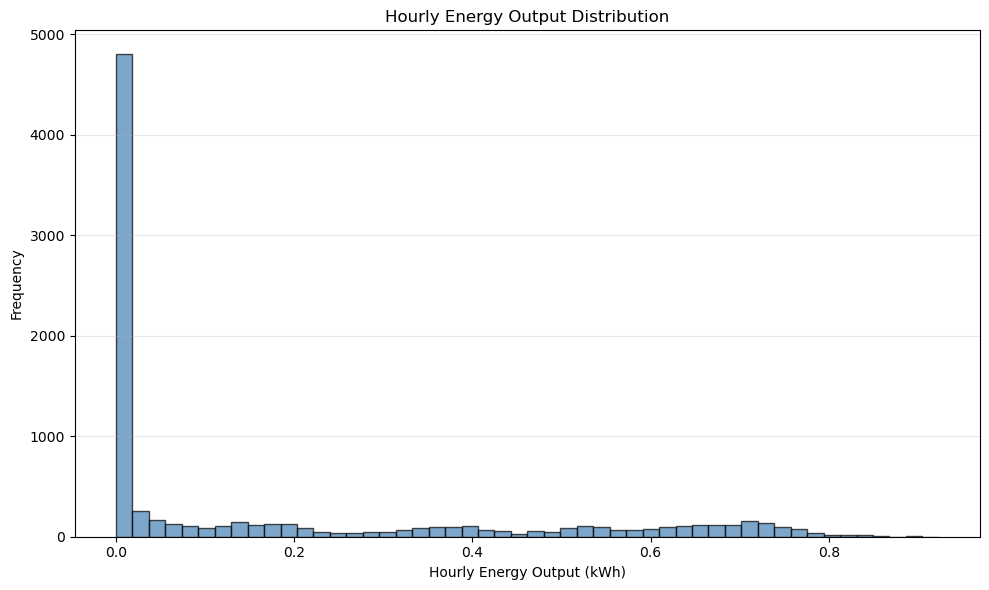

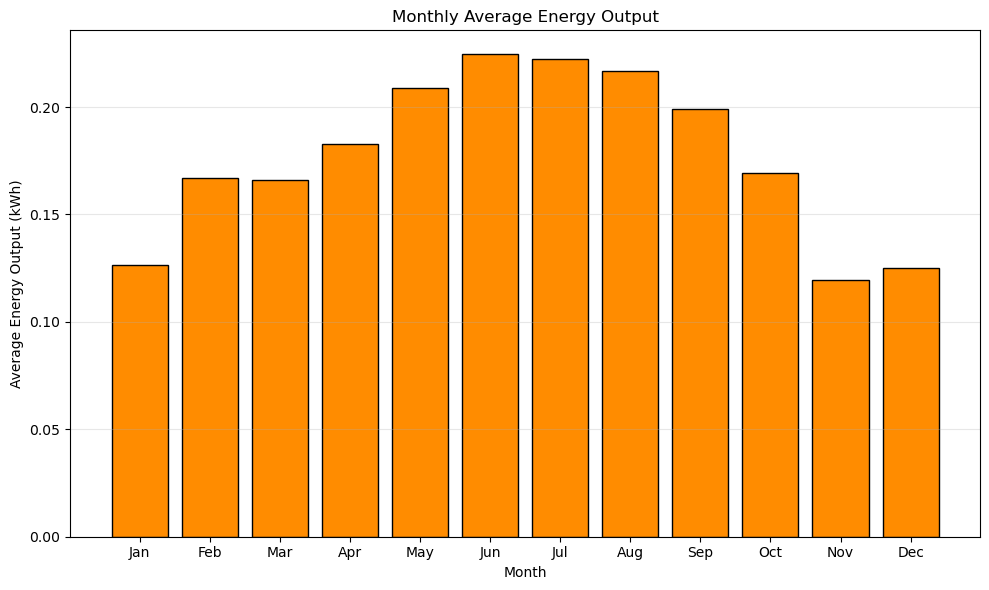

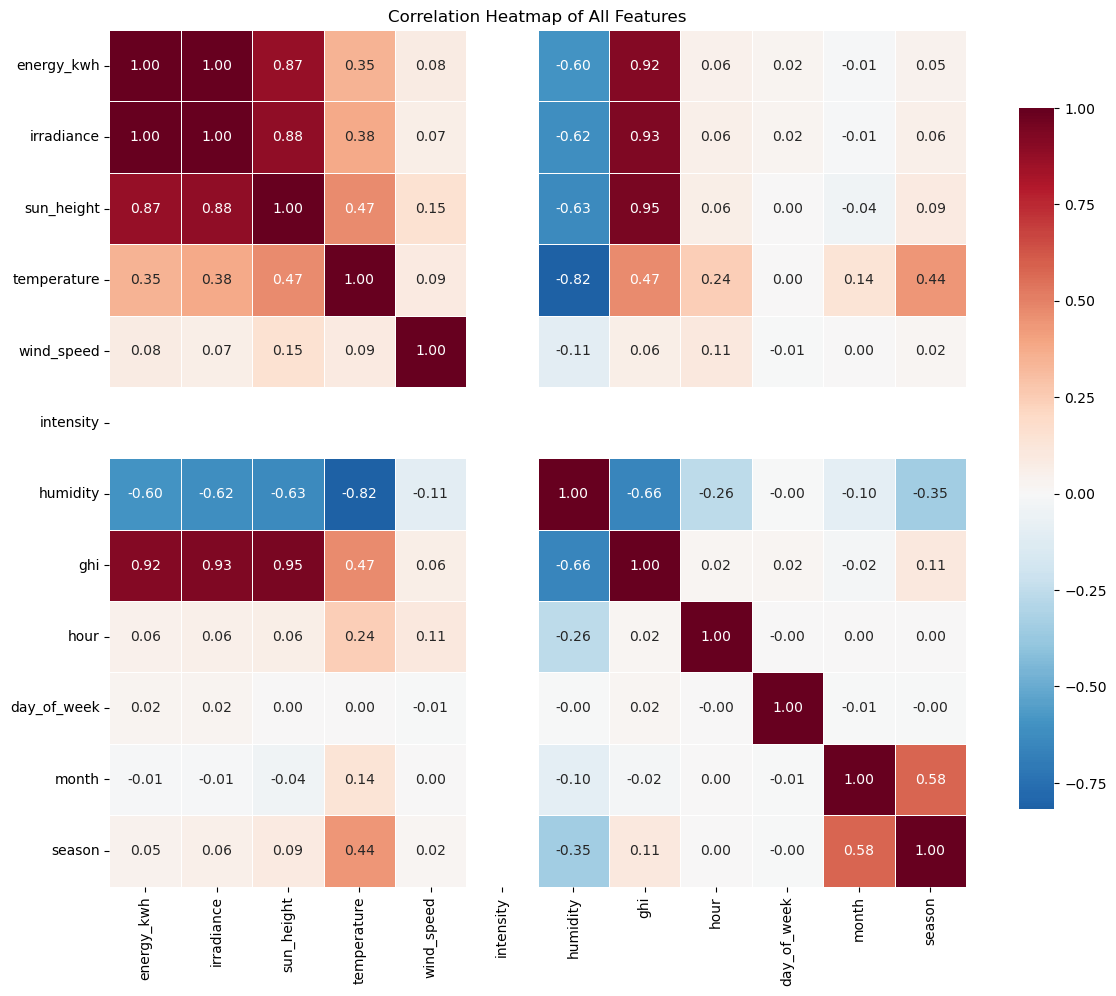

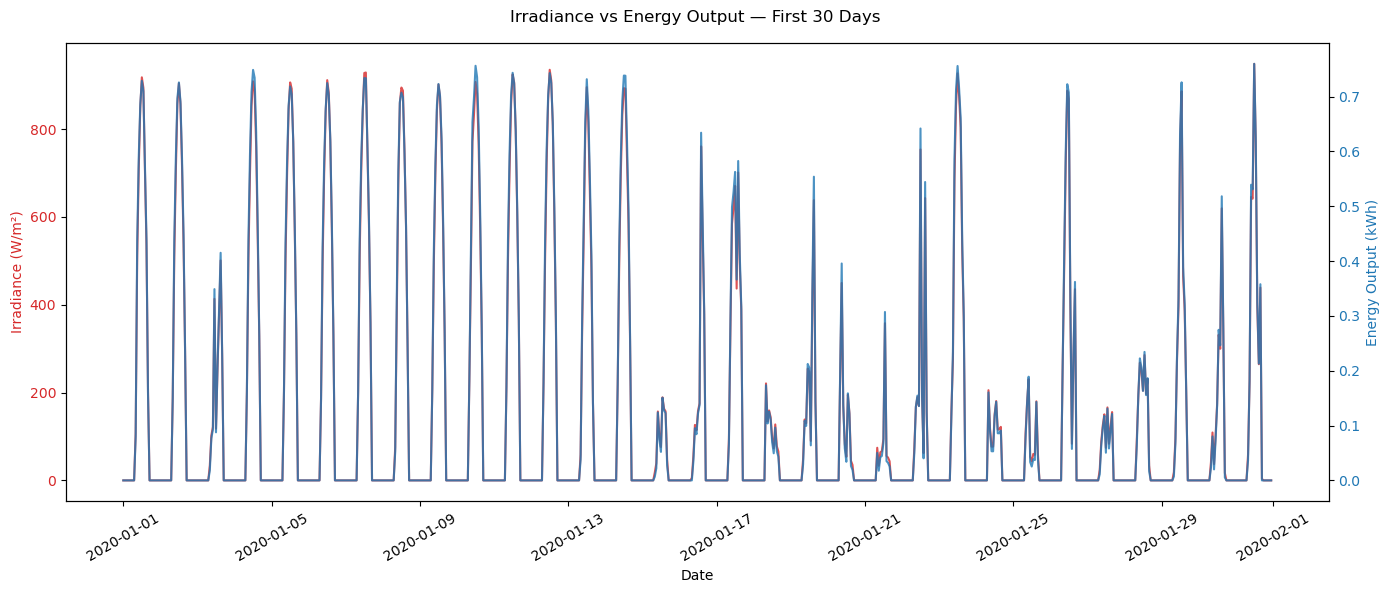

  4 EDA plots saved to c:\Users\User\OneDrive\Documents\Codes\2nd Sem Python Codes\Intelligent Systems\renewable_energy_ann\figures


In [6]:
print("[Step 3] Generating EDA figures...")

# Histogram of hourly energy output
plt.figure(figsize=(10, 6))
plt.hist(df['energy_kwh'], bins=50, color='steelblue', edgecolor='black', alpha=0.7)
plt.xlabel('Hourly Energy Output (kWh)')
plt.ylabel('Frequency')
plt.title('Hourly Energy Output Distribution')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'hourly_energy_distribution.png'), dpi=150)
plt.show()

# Monthly average bar chart
monthly_avg = df.groupby('month')['energy_kwh'].mean()
month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
               'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
plt.figure(figsize=(10, 6))
plt.bar(range(1, 13), monthly_avg.values, color='darkorange', edgecolor='black')
plt.xticks(range(1, 13), month_names)
plt.xlabel('Month')
plt.ylabel('Average Energy Output (kWh)')
plt.title('Monthly Average Energy Output')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'monthly_avg_output.png'), dpi=150)
plt.show()

# Correlation heatmap
numeric_df = df.drop(columns=['datetime'])
plt.figure(figsize=(12, 10))
corr_matrix = numeric_df.corr()
sns.heatmap(corr_matrix, annot=True, cmap='RdBu_r', center=0,
            square=True, fmt='.2f', cbar_kws={"shrink": .8}, linewidths=0.5)
plt.title('Correlation Heatmap of All Features')
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'correlation_heatmap.png'), dpi=150)
plt.show()

# Time series: irradiance vs energy (first 30 days)
df_30 = df[df['datetime'] < '2020-02-01'].copy()
fig, ax1 = plt.subplots(figsize=(14, 6))
ax1.set_xlabel('Date')
ax1.set_ylabel('Irradiance (W/m²)', color='tab:red')
ax1.plot(df_30['datetime'], df_30['irradiance'], color='tab:red', alpha=0.8, label='Irradiance')
ax1.tick_params(axis='y', labelcolor='tab:red')
ax1.tick_params(axis='x', rotation=30)
ax2 = ax1.twinx()
ax2.set_ylabel('Energy Output (kWh)', color='tab:blue')
ax2.plot(df_30['datetime'], df_30['energy_kwh'], color='tab:blue', alpha=0.8, label='Energy Output')
ax2.tick_params(axis='y', labelcolor='tab:blue')
fig.suptitle('Irradiance vs Energy Output — First 30 Days')
fig.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'irradiance_vs_energy_30days.png'), dpi=150)
plt.show()
print(f"  4 EDA plots saved to {FIGURES_DIR}")

### Step 4: Feature Scaling & Chronological Split
Normalizing the features to the [0,1] range and splitting the dataset into Train (70%), Validation (15%), and Test (15%).

In [7]:
print("[Step 4] Scaling features and splitting data...")

X = df[FEATURES].values
y = df[TARGET].values.reshape(-1, 1)

scaler_X = MinMaxScaler(feature_range=(0, 1))
scaler_y = MinMaxScaler(feature_range=(0, 1))
X_scaled = scaler_X.fit_transform(X)
y_scaled = scaler_y.fit_transform(y)

# Save scalers
joblib.dump(scaler_X, os.path.join(BASE_DIR, 'scaler_X.pkl'))
joblib.dump(scaler_y, os.path.join(BASE_DIR, 'scaler_y.pkl'))

# Chronological split: 70% train, 15% val, 15% test
n = len(X_scaled)
train_end = int(0.70 * n)
val_end = int(0.85 * n)

X_train, y_train = X_scaled[:train_end], y_scaled[:train_end]
X_val, y_val = X_scaled[train_end:val_end], y_scaled[train_end:val_end]
X_test, y_test = X_scaled[val_end:], y_scaled[val_end:]

print(f"  Train:      {len(X_train)} samples ({len(X_train)/n*100:.1f}%)")
print(f"  Validation: {len(X_val)} samples ({len(X_val)/n*100:.1f}%)")
print(f"  Test:       {len(X_test)} samples ({len(X_test)/n*100:.1f}%)")

[Step 4] Scaling features and splitting data...
  Train:      6148 samples (70.0%)
  Validation: 1318 samples (15.0%)
  Test:       1318 samples (15.0%)


### Step 5: Build ANN Model
Creating a standard Multi-Layer Perceptron (MLP) for regression in Keras.

In [9]:
print("[Step 5] Building ANN model...")
print(f"  Input:  {len(FEATURES)} neurons  → {FEATURES}")
print(f"  Hidden: 10 neurons (ReLU)")
print(f"  Hidden:  8 neurons (ReLU)")
print(f"  Output:  1 neuron  (Linear)")

model = keras.Sequential([
    keras.layers.Dense(10, activation='relu', input_shape=(len(FEATURES),), name='hidden_1'),
    keras.layers.Dense(8, activation='relu', name='hidden_2'),
    keras.layers.Dense(1, activation='linear', name='output')
], name='SolarOutputPredictor')

optimizer = keras.optimizers.Adam(learning_rate=LEARNING_RATE)
model.compile(optimizer=optimizer, loss='mse', metrics=['mae'])
model.summary()

[Step 5] Building ANN model...
  Input:  5 neurons  → ['irradiance', 'temperature', 'wind_speed', 'humidity', 'hour']
  Hidden: 10 neurons (ReLU)
  Hidden:  8 neurons (ReLU)
  Output:  1 neuron  (Linear)


Model: "SolarOutputPredictor"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ hidden_1 (Dense)                │ (None, 10)             │            60 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_2 (Dense)                │ (None, 8)              │            88 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 157 (628.00 B)

 Trainable params: 157 (628.00 B)

 Non-trainable params: 0 (0.00 B)

### Step 6: Train the Model
Training the ANN using `EarlyStopping` and `ModelCheckpoint` callbacks to preserve the best weights and prevent overfitting.

In [10]:
print(f"\n[Step 6] Training for up to {EPOCHS} epochs...")

callbacks = [
    EarlyStopping(monitor='val_loss', patience=PATIENCE, restore_best_weights=True, verbose=1),
    ModelCheckpoint(filepath=MODEL_PATH_KERAS, monitor='val_loss', save_best_only=True, verbose=1)
]

history = model.fit(
    X_train, y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(X_val, y_val),
    callbacks=callbacks,
    verbose=1
)

print(f"\n  Training stopped at epoch {len(history.history['loss'])}")
print(f"  Best model saved to: {MODEL_PATH_KERAS}")


[Step 6] Training for up to 150 epochs...
Epoch 1/150
164/193 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0570 - mae: 0.1918 
Epoch 1: val_loss improved from None to 0.00715, saving model to c:\Users\User\OneDrive\Documents\Codes\2nd Sem Python Codes\Intelligent Systems\renewable_energy_ann\best_model.keras

Epoch 1: finished saving model to c:\Users\User\OneDrive\Documents\Codes\2nd Sem Python Codes\Intelligent Systems\renewable_energy_ann\best_model.keras
193/193 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0353 - mae: 0.1450 - val_loss: 0.0071 - val_mae: 0.0663
Epoch 2/150
171/193 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0044 - mae: 0.0504
Epoch 2: val_loss improved from 0.00715 to 0.00099, saving model to c:\Users\User\OneDrive\Documents\Codes\2nd Sem Python Codes\Intelligent Systems\renewable_energy_ann\best_model.keras

Epoch 2: finished saving model to c:\Users\User\OneDrive\Documents\Codes\2nd Sem Python Codes\Intelligent Systems\renewable_energy_ann\best_model.keras
193/193 ━━

### Step 7: Evaluate ANN
Evaluating the test set metrics (RMSE, MAE, R²) and visually comparing the true vs predicted outputs.

[Step 7] Evaluating ANN on test set...
  Model also saved as .h5: c:\Users\User\OneDrive\Documents\Codes\2nd Sem Python Codes\Intelligent Systems\renewable_energy_ann\best_model.h5
  ANN RMSE: 0.003402
  ANN MAE:  0.002187
  ANN R²:   0.999761


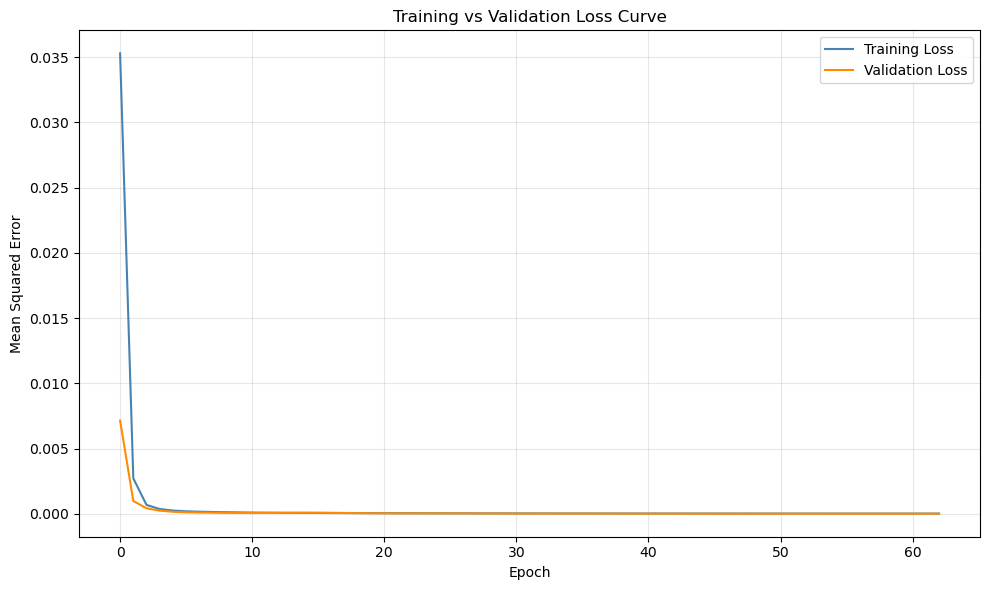

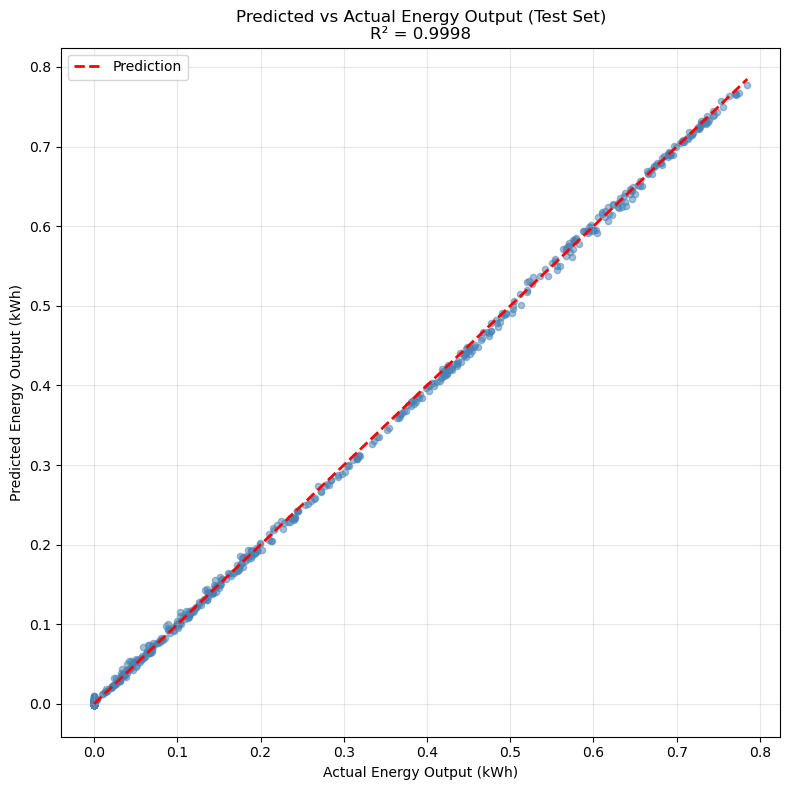

  Saved: loss_curve.png, pred_vs_actual.png


In [12]:
print("[Step 7] Evaluating ANN on test set...")

# Load best model
best_model = keras.models.load_model(MODEL_PATH_KERAS)
best_model.save(MODEL_PATH)
print(f"  Model also saved as .h5: {MODEL_PATH}")

# Predict
y_pred_scaled = best_model.predict(X_test, verbose=0)
y_pred = scaler_y.inverse_transform(y_pred_scaled)
y_true = scaler_y.inverse_transform(y_test)

# Metrics
rmse_ann = np.sqrt(mean_squared_error(y_true, y_pred))
mae_ann = mean_absolute_error(y_true, y_pred)
r2_ann = r2_score(y_true, y_pred)

print(f"  ANN RMSE: {rmse_ann:.6f}")
print(f"  ANN MAE:  {mae_ann:.6f}")
print(f"  ANN R²:   {r2_ann:.6f}")

# Loss curve
plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], label='Training Loss', color='steelblue')
plt.plot(history.history['val_loss'], label='Validation Loss', color='darkorange')
plt.xlabel('Epoch')
plt.ylabel('Mean Squared Error')
plt.title('Training vs Validation Loss Curve')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'loss_curve.png'), dpi=150)
plt.show()

# Predicted vs Actual
plt.figure(figsize=(8, 8))
plt.scatter(y_true, y_pred, alpha=0.5, color='steelblue', s=20)
max_val = max(y_true.max(), y_pred.max())
plt.plot([0, max_val], [0, max_val], 'r--', lw=2, label='Prediction')
plt.xlabel('Actual Energy Output (kWh)')
plt.ylabel('Predicted Energy Output (kWh)')
plt.title(f'Predicted vs Actual Energy Output (Test Set)\nR² = {r2_ann:.4f}')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'pred_vs_actual.png'), dpi=150)
plt.show()
print("  Saved: loss_curve.png, pred_vs_actual.png")

### Step 8 & 9: Linear Regression Baseline & Save Results
Comparing the ANN against a simple linear regression baseline, followed by exporting the results.